# Data Analysis — Person 2
**Purpose:** Perform exploratory data analysis and produce charts, summaries, and written interpretations.  
**Deliverables:** Jupyter Notebook with code, charts, and written explanations. Upload to GitHub after completion.

---

**How to use:**  
1. Place the cleaned dataset file in the same directory as this notebook (e.g., `clean_data.csv`).  
2. Update the `DATA_PATH` variable in the Data Loading cell if necessary.  
3. Run cells top-to-bottom.


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)
sns.set(style='whitegrid')

In [5]:
# Data Loading
# Replace 'clean_data.csv' with your actual filename if different.
DATA_PATH = r'C:\Users\Admin\Desktop\Amazon\cleaned_amazon_data.csv'

try:
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded data with shape: {df.shape}')
except FileNotFoundError:
    print(f'File not found: {DATA_PATH}.\nPlease put the cleaned CSV in the notebook folder or update DATA_PATH.')
    # create an example dataframe for demonstration
    df = pd.DataFrame({
        'order_id': range(1,101),
        'product_category': np.random.choice(['A','B','C','D','E'], 100),
        'product_id': np.random.randint(1000, 1100, 100),
        'unit_price': np.round(np.random.uniform(5, 200, 100),2),
        'quantity': np.random.randint(1, 10, 100),
        'revenue': lambda x: x['unit_price'] * x['quantity'],
        'customer_id': np.random.randint(10000,10100,100),
        'date': pd.date_range(end=pd.Timestamp.today(), periods=100).astype(str)
    })
    df['revenue'] = df['unit_price'] * df['quantity']
    print('Created a demo dataframe for illustration.')

Loaded data with shape: (243, 11)


## Quick Data Peek
Show first rows and dtypes.

In [6]:
df.head()


,order_id,date,product,category,price,quantity,total_sales,customer_name,customer_location,payment_method,status
0,ORD0001,14-03-2025,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled
1,ORD0002,20-03-2025,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending
2,ORD0003,15-02-2025,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled
3,ORD0004,19-02-2025,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending
4,ORD0005,03-10-2025,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   order_id           243 non-null    object
 1   date               243 non-null    object
 2   product            243 non-null    object
 3   category           243 non-null    object
 4   price              243 non-null    int64 
 5   quantity           243 non-null    int64 
 6   total_sales        243 non-null    int64 
 7   customer_name      243 non-null    object
 8   customer_location  243 non-null    object
 9   payment_method     243 non-null    object
 10  status             243 non-null    object
dtypes: int64(3), object(8)
memory usage: 21.0+ KB


## Statistical Summary
Compute mean, median, min, max, std for numeric columns and a short written interpretation.

In [8]:
# Statistical summary for numeric columns
num_summary = df.select_dtypes(include=[np.number]).describe().T
num_summary['median'] = df.select_dtypes(include=[np.number]).median()
num_summary = num_summary[['count','mean','median','std','min','25%','50%','75%','max']]
num_summary

,count,mean,median,std,min,25%,50%,75%,max
price,243.0,318.909465,150.0,356.717913,15.0,40.0,150.0,500.0,1200.0
quantity,243.0,2.814815,3.0,1.426819,1.0,2.0,3.0,4.0,5.0
total_sales,243.0,855.329218,300.0,1042.969623,15.0,100.0,300.0,1200.0,4000.0


**Interpretation (example):**  
Review the mean and median to check skewness. Large differences between mean and median may indicate skewed distributions or outliers. Use the standard deviation to understand spread. For decision-making, flag columns with extremely high variance for further inspection.

## Top Product Categories
Bar chart showing total revenue (or count) by product category and interpretation.

In [10]:
# Aggregate revenue by product category (fallback to counts if revenue not present)
agg_col = 'revenue' if 'revenue' in df.columns else 'quantity'
by_cat = df.groupby('category')[agg_col].agg(['sum','count']).reset_index().sort_values('sum', ascending=False)
by_cat.head()

,category,sum,count
2,Electronics,348,118
1,Clothing,115,40
4,Home Appliances,80,33
3,Footwear,72,27
0,Books,69,25


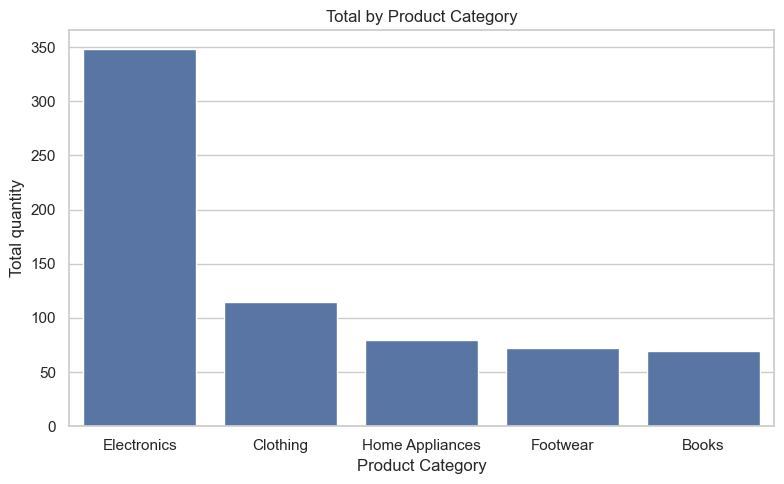

In [11]:
# Bar chart: total revenue by category
plt.figure(figsize=(8,5))
sns.barplot(data=by_cat, x='category', y='sum')
plt.xlabel('Product Category')
plt.ylabel(f'Total {agg_col}')
plt.title('Total by Product Category')
plt.tight_layout()
plt.show()

**Interpretation (example):**  
The bar chart highlights which categories drive the most revenue. Focus marketing and inventory decisions on top categories. If one category dominates, consider whether that exposes the business to category-specific risk.

## Relationship Analysis
Scatter plots, correlation matrix to find relationships between numeric variables.

In [12]:
# Select numeric columns and compute correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()
    display(corr)
else:
    print('Not enough numeric columns for correlation.')

,price,quantity,total_sales
price,1.000000,-0.083535,0.830497
quantity,-0.083535,1.000000,0.287509
total_sales,0.830497,0.287509,1.000000


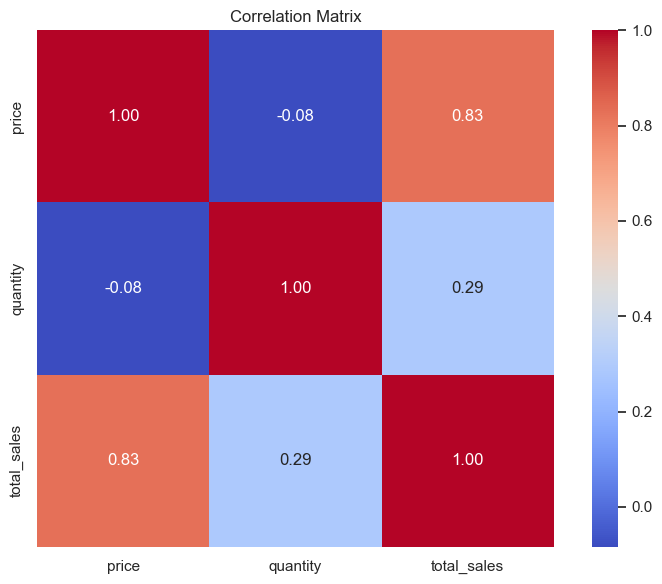

In [13]:
# Correlation heatmap
if len(numeric_cols) >= 2:
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

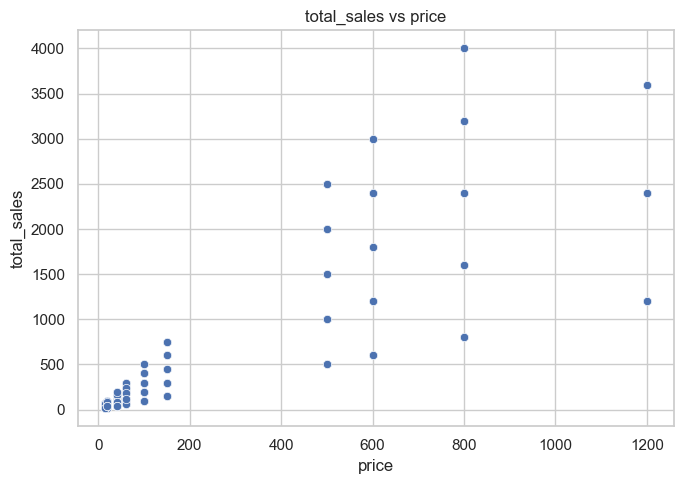

In [14]:
# Example scatter: unit_price vs revenue (or quantity)
x_col = 'unit_price' if 'unit_price' in df.columns else numeric_cols[0]
y_col = 'revenue' if 'revenue' in df.columns else numeric_cols[-1]
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x=x_col, y=y_col)
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f'{y_col} vs {x_col}')
plt.tight_layout()
plt.show()

**Interpretation (example):**  
Scatter plots and correlations help detect linear relationships and potential predictors of revenue. Strong correlation (>|0.6|) merits further modeling or causal investigation.

## Identify Top Performers
Top products, customers, or salespeople (if available).

In [15]:
# Top products by revenue
if 'product_id' in df.columns and 'revenue' in df.columns:
    top_products = df.groupby('product_id')['revenue'].sum().reset_index().sort_values('revenue', ascending=False).head(10)
    top_products
else:
    print('product_id or revenue column missing; adapt to available columns.')

product_id or revenue column missing; adapt to available columns.


**Interpretation (example):**  
List the top-selling products or customers and consider inventory, promotions, or contract renewals targeting these high-value items or clients.

## Key Enterprise Decision Metrics
Compute and explain metrics such as: total revenue, average order value (AOV), customer lifetime value (approx.), conversion/retention proxies, and margin if cost data exists.

In [16]:
# Example enterprise metrics
metrics = {}
metrics['total_revenue'] = df['revenue'].sum() if 'revenue' in df.columns else np.nan
metrics['num_orders'] = df['order_id'].nunique() if 'order_id' in df.columns else len(df)
metrics['avg_order_value'] = metrics['total_revenue'] / metrics['num_orders'] if metrics['num_orders'] else np.nan
metrics['num_customers'] = df['customer_id'].nunique() if 'customer_id' in df.columns else np.nan
metrics

{'total_revenue': nan,
 'num_orders': 243,
 'avg_order_value': nan,
 'num_customers': nan}

**Interpretation (example):**  
- **Total Revenue:** top-line performance.  
- **Avg Order Value (AOV):** helps set pricing and promotional strategy.  
- **Top Customers:** consider loyalty programmes.  
- If cost data exists, compute gross margin and contribution margin for product-level profitability.

## Written Explanations and Next Steps
Include a short narrative for each chart and recommended decisions. Example structure provided below.

**Narrative Template (for each chart):**  
1. **What the chart shows** — short factual description.  
2. **Key insight** — the most important observation.  
3. **Business implication** — what decision/action this suggests.  
4. **Caveats / next analysis** — data quality issues or follow-ups (seasonality, cohort analysis, A/B tests).
